In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = df.Level
X

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Level, dtype: int64

In [4]:
y = df.Salary
y

0      45000
1      50000
2      60000
3      80000
4     110000
5     150000
6     200000
7     300000
8     500000
9    1000000
Name: Salary, dtype: int64

Text(0, 0.5, 'Salary')

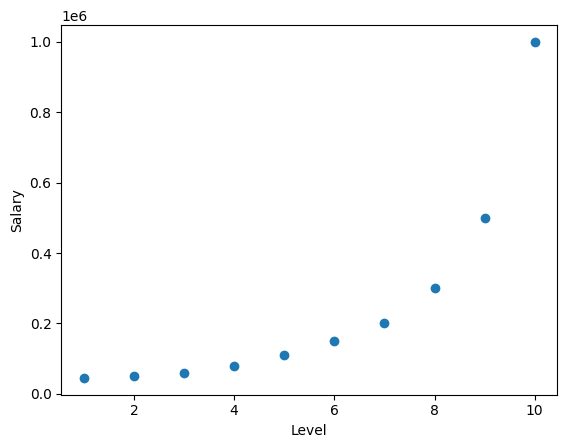

In [5]:
plt.scatter(X, y)
plt.xlabel("Level")
plt.ylabel("Salary")

# LINEAR REGRESSION

In [6]:
def r2score(y_pred, y):
    rss = np.sum((y_pred - y) ** 2)
    tss = np.sum((y-y.mean()) ** 2)

    r2 = 1 - (rss / tss)
    return r2

In [7]:
class LinearRegression:
    def __init__(self, X_data, y_target, learning_rate=0.01, num_epochs=10000):
        self.X_data = X_data
        self.y_target = y_target
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.num_samples = self.X_data.shape[0]

        # Initial Coefficients
        self.theta = np.random.randn(self.X_data.shape[1])
        self.losses = []

    def compute_loss(self, y_pred, y_target):
        loss = (y_pred-y_target)*(y_pred-y_target)
        loss = np.mean(loss)
        return loss

    def predict(self, X_data):
        y_pred = X_data.dot(self.theta)
        return y_pred

    def fit(self):
        for epoch in range(self.num_epochs):
            # predict
            y_pred = self.predict(self.X_data)

            # compute loss
            loss = self.compute_loss(y_pred, self.y_target)
            self.losses.append(loss)

            # compute gradient
            k = 2*(y_pred-self.y_target)
            gradients = self.X_data.T.dot(k)/self.num_samples

            # update weight
            self.theta = self.theta - self.learning_rate*gradients

            print(f'Epoch: {epoch} - Loss: {loss}')

        return {
            'loss': sum(self.losses)/len(self.losses),
            'weight': self.theta
        }

In [8]:
X_linear = X.values.reshape(-1, 1)
X_linear = np.hstack((np.ones((X_linear.shape[0], 1)), X_linear))

In [9]:
X_linear

array([[ 1.,  1.],
       [ 1.,  2.],
       [ 1.,  3.],
       [ 1.,  4.],
       [ 1.,  5.],
       [ 1.,  6.],
       [ 1.,  7.],
       [ 1.,  8.],
       [ 1.,  9.],
       [ 1., 10.]])

In [10]:
linear_model = LinearRegression(X_linear, y, num_epochs=100)
linear_model.fit()

Epoch: 0 - Loss: 142912695898.4765
Epoch: 1 - Loss: 40361197252.02531
Epoch: 2 - Loss: 35586142950.199814
Epoch: 3 - Loss: 35297798365.30861
Epoch: 4 - Loss: 35215890978.79817
Epoch: 5 - Loss: 35144030847.15447
Epoch: 6 - Loss: 35073202491.92839
Epoch: 7 - Loss: 35002987485.88612
Epoch: 8 - Loss: 34933361887.00385
Epoch: 9 - Loss: 34864319892.569756
Epoch: 10 - Loss: 34795856571.55791
Epoch: 11 - Loss: 34727967072.03429
Epoch: 12 - Loss: 34660646584.46362
Epoch: 13 - Loss: 34593890339.701035
Epoch: 14 - Loss: 34527693608.577614
Epoch: 15 - Loss: 34462051701.56184
Epoch: 16 - Loss: 34396959968.42723
Epoch: 17 - Loss: 34332413797.922985
Epoch: 18 - Loss: 34268408617.447166
Epoch: 19 - Loss: 34204939892.72285
Epoch: 20 - Loss: 34142003127.476906
Epoch: 21 - Loss: 34079593863.12147
Epoch: 22 - Loss: 34017707678.43805
Epoch: 23 - Loss: 33956340189.264366
Epoch: 24 - Loss: 33895487048.183735
Epoch: 25 - Loss: 33835143944.21709
Epoch: 26 - Loss: 33775306602.517586
Epoch: 27 - Loss: 3371597078

{'loss': np.float64(33803501826.892956),
 'weight': array([-62217.28551167,  61757.92544285])}

In [11]:
y_pred = linear_model.predict(X_linear)

In [12]:
r2score(y_pred, y)

np.float64(0.6219617591338208)

In [13]:
linear_model.theta

array([-62217.28551167,  61757.92544285])

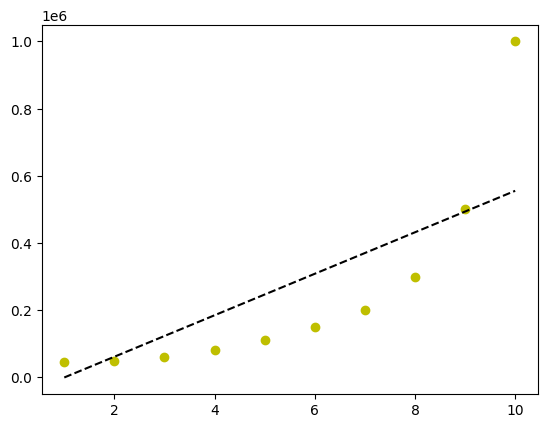

In [14]:
plt.plot(X, y, 'yo', X, linear_model.theta[1]*X + linear_model.theta[0], '--k')
plt.show()

# POLYNOMIAL REGRESSION

In [15]:
def create_polynomial_features(X, degree=2):
    """Creates the polynomial features
    Args:
        X: A array tensor for the data.
        degree: A intege for the degree of
        the generated polynomial function.
    """
    X_new = X
    for d in range(2, degree+1):
        X_new = np.c_[X_new, np.power(X, d)]
    return X_new

In [16]:
X_poly = create_polynomial_features(X, degree=2)
X_poly

array([[  1,   1],
       [  2,   4],
       [  3,   9],
       [  4,  16],
       [  5,  25],
       [  6,  36],
       [  7,  49],
       [  8,  64],
       [  9,  81],
       [ 10, 100]])

In [17]:
X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [18]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.0001, num_epochs=10000)
poly_model.fit()

Epoch: 0 - Loss: 142931638207.56024
Epoch: 1 - Loss: 45673247719.07338
Epoch: 2 - Loss: 22698300570.894276
Epoch: 3 - Loss: 17268184767.873722
Epoch: 4 - Loss: 15981944305.255611
Epoch: 5 - Loss: 15674439682.633575
Epoch: 6 - Loss: 15598104226.661633
Epoch: 7 - Loss: 15576371962.540241
Epoch: 8 - Loss: 15567540194.085241
Epoch: 9 - Loss: 15561759257.809576
Epoch: 10 - Loss: 15556702781.242725
Epoch: 11 - Loss: 15551821299.889225
Epoch: 12 - Loss: 15546985032.869589
Epoch: 13 - Loss: 15542163323.370459
Epoch: 14 - Loss: 15537348926.457209
Epoch: 15 - Loss: 15532540126.794933
Epoch: 16 - Loss: 15527736515.076038
Epoch: 17 - Loss: 15522937990.464863
Epoch: 18 - Loss: 15518144524.987469
Epoch: 19 - Loss: 15513356107.883453
Epoch: 20 - Loss: 15508572732.462475
Epoch: 21 - Loss: 15503794392.999975
Epoch: 22 - Loss: 15499021084.003992
Epoch: 23 - Loss: 15494252800.041912
Epoch: 24 - Loss: 15489489535.699635
Epoch: 25 - Loss: 15484731285.571857
Epoch: 26 - Loss: 15479978044.259802
Epoch: 27 - 

{'loss': np.float64(11093651090.784122),
 'weight': array([ 14602.40336937, -47838.73046382,  12584.3903644 ])}

In [19]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

np.float64(0.8736086322256441)

In [20]:
poly_model.theta

array([ 14602.40336937, -47838.73046382,  12584.3903644 ])

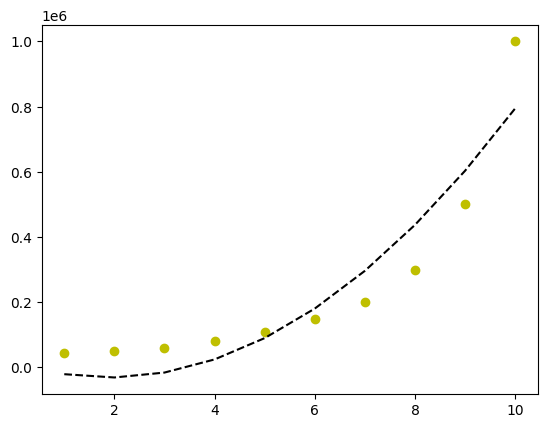

In [21]:
X_plot = df.Level
y_func = poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()